# 01 Dataset discovery

Exploratory overview of the final country × year panel (`dataset.csv`).

**Run location:** start Jupyter from the project root, or open this notebook so the kernel’s current working directory is either the repo root or `notebooks/` the loader below checks both.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


def resolve_data_csv():
    """Prefer dataset.csv; fall back to sample.csv with a warning."""
    cwd = Path.cwd().resolve()
    roots = [cwd, cwd.parent]
    for name in ("dataset.csv", "sample.csv"):
        for root in roots:
            p = root / "data" / name
            if p.is_file():
                if name == "sample.csv":
                    print(
                        "WARNING: data/dataset.csv not found — using data/sample.csv (100 rows only)."
                    )
                return p, name
    raise FileNotFoundError(
        "Could not find data/dataset.csv or data/sample.csv. "
        "Run: cd src && python build-dataset.py (see README)."
    )


csv_path, csv_name = resolve_data_csv()
df = pd.read_csv(csv_path)
print(f"Loaded: {csv_path}")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

Loaded: C:\Users\PE\Documents\python\EconomicShockDetector\data\dataset.csv
Shape: 10,603 rows × 24 columns


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10603 entries, 0 to 10602
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   country                10603 non-null  object 
 1   year                   10603 non-null  int64  
 2   current_account_pct    7159 non-null   float64
 3   debt_service_pct       4507 non-null   float64
 4   domestic_credit_pct    1405 non-null   float64
 5   external_debt_pct      5240 non-null   float64
 6   fdi_inflows            8670 non-null   float64
 7   fx_reserves_months     6546 non-null   float64
 8   gdp_growth             10603 non-null  float64
 9   gdp_per_capita         10521 non-null  float64
 10  gni_per_capita_growth  5442 non-null   float64
 11  gov_expenditure        4347 non-null   float64
 12  govt_debt_pct_gdp      1573 non-null   float64
 13  inflation              8272 non-null   float64
 14  trade_openness         8179 non-null   float64
 15  un

In [3]:
df.describe()

,year,current_account_pct,debt_service_pct,domestic_credit_pct,external_debt_pct,fdi_inflows,fx_reserves_months,gdp_growth,gdp_per_capita,gni_per_capita_growth,gov_expenditure,govt_debt_pct_gdp,inflation,trade_openness,unemployment,gdp_growth_lag1,gdp_growth_delta,economic_shock
count,10603.00000,7159.000000,4507.000000,1405.000000,5240.000000,8670.000000,6546.000000,10603.000000,10521.000000,5442.000000,4347.000000,1573.000000,8272.000000,8179.000000,5771.000000,10603.000000,10603.000000,10603.000000
mean,1995.35622,-2.762381,16.517974,72.074479,60.436527,5.052233,4.334482,3.650857,12441.944584,2.189513,26.622044,56.861702,23.293065,77.905932,8.073421,3.625253,0.025604,0.082901
std,16.88116,12.515793,14.501811,62.516644,74.573150,36.877917,4.489844,6.800040,19250.712035,7.661901,19.101771,78.735252,331.625304,53.364779,6.000957,6.822961,8.090809,0.275746
min,1962.00000,-147.997312,0.000000,-9.313642,0.000000,-391.555119,0.002215,-64.047107,122.678901,-51.710959,2.045768,-1.170726,-17.640424,0.020999,0.100000,-64.047107,-126.198481,0.000000
25%,1982.00000,-6.975260,6.170635,31.213591,26.023280,0.379617,1.827914,1.169158,1347.213064,-0.607726,17.029239,29.563599,2.160545,44.669975,3.685000,1.141197,-2.587663,0.000000
50%,1997.00000,-2.879705,12.607544,54.018811,43.305579,1.569344,3.290999,3.786513,3998.797292,2.291434,25.100040,48.139023,4.934043,66.354988,6.365000,3.781388,-0.025656,0.000000
75%,2010.00000,0.937123,22.679702,85.505074,69.993746,4.027168,5.309421,6.307230,16264.894039,5.154945,34.039632,68.999003,10.261861,96.590501,10.919500,6.310500,2.380053,0.000000
max,2022.00000,311.746071,156.858151,393.368634,1343.269962,1709.827224,79.237218,149.972963,214359.605826,101.586608,758.958242,2003.941756,23773.131774,863.195099,38.800000,149.972963,137.165264,1.000000


In [4]:
df.head()

,country,year,current_account_pct,debt_service_pct,domestic_credit_pct,external_debt_pct,fdi_inflows,fx_reserves_months,gdp_growth,gdp_per_capita,...,trade_openness,unemployment,country_name,region,income_group,lending_type,gdp_growth_lag1,gdp_growth_delta,is_crisis_decade,economic_shock
0,ABW,1988,-7.425094,NaN,NaN,NaN,2.055486,3.384498,18.648649,22468.507120,...,NaN,NaN,Aruba,Latin America & Caribbean,High income,Not classified,16.078431,2.570217,1980s,0
1,ABW,1989,-6.714859,NaN,NaN,NaN,0.186908,2.921822,12.129841,24730.396448,...,NaN,NaN,Aruba,Latin America & Caribbean,High income,Not classified,18.648649,-6.518808,1980s,0
2,ABW,1990,-20.679328,NaN,NaN,NaN,17.063550,2.217400,3.961402,24763.653810,...,NaN,NaN,Aruba,Latin America & Caribbean,High income,Not classified,12.129841,-8.168439,1990s,0
3,ABW,1991,-24.023062,NaN,NaN,NaN,21.185138,1.179546,7.962872,25460.363027,...,NaN,NaN,Aruba,Latin America & Caribbean,High income,Not classified,3.961402,4.001470,1990s,0
4,ABW,1992,4.568765,NaN,NaN,NaN,-3.857809,1.292875,5.882354,25743.445501,...,NaN,NaN,Aruba,Latin America & Caribbean,High income,Not classified,7.962872,-2.080518,1990s,0


## Target: `economic_shock`
Absolute and relative class frequencies (imbalance check vs cadrage: minority between 5% and 25%).

In [5]:
vc = df["economic_shock"].value_counts().sort_index()
vc_norm = df["economic_shock"].value_counts(normalize=True).sort_index()
print("value_counts:")
print(vc)
print()
print("value_counts(normalize=True):")
print(vc_norm)

value_counts:
economic_shock
0    9724
1     879
Name: count, dtype: int64

value_counts(normalize=True):
economic_shock
0    0.917099
1    0.082901
Name: proportion, dtype: float64


## Class imbalance bar chart

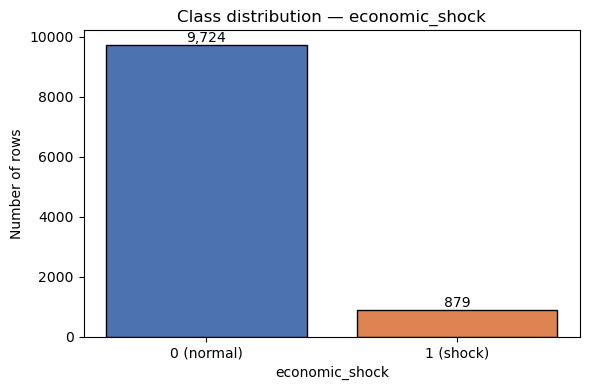

In [6]:
counts = df["economic_shock"].value_counts().sort_index()
labels = [f"{int(i)} (" + ("normal" if i == 0 else "shock") + ")" for i in counts.index]

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(labels, counts.values, color=["#4C72B0", "#DD8452"], edgecolor="black")
ax.set_ylabel("Number of rows")
ax.set_xlabel("economic_shock")
ax.set_title("Class distribution — economic_shock")
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h, f"{int(h):,}", ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.show()